# Bài 1 — Titanic: Logistic Regression vs Linear Regression

**Tuần 4 — Buổi 7: Phân loại 1 (Logistic Regression & KNN)**

Mục tiêu:
1. Dùng lại bộ dữ liệu Titanic đã EDA/tiền xử lý ở tuần trước.
2. Dùng **Logistic Regression** để dự đoán `survived`.
3. Dùng cùng cách chia train/val/test (70/15/15, stratify) như bài trước.
4. Đánh giá bằng Accuracy, Precision, Recall, F1, Confusion Matrix.
5. So sánh với **Linear Regression** (hồi quy tuyến tính, dùng ngưỡng 0.5 để phân loại) và nhận xét mô hình nào phù hợp hơn.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Sẵn sàng.")


Sẵn sàng.


## 1. Tải & tiền xử lý dữ liệu (giống bài tuần trước)

Loại bỏ các cột rò rỉ nhãn / dư thừa (`alive`, `who`, `adult_male`, `class`, `deck`, `embark_town`, `alone`),
chỉ giữ: `survived, pclass, sex, age, sibsp, parch, fare, embarked`.


In [2]:
df = sns.load_dataset("titanic")

leaky = ["alive", "who", "adult_male", "class", "deck", "embark_town", "alone"]
leaky = [c for c in leaky if c in df.columns]
df = df.drop(columns=leaky)

print("Shape:", df.shape)
df.head()


Shape: (891, 8)


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## 2. Chia train / validation / test (70/15/15, stratify)

Dùng đúng cách chia đã làm ở bài Titanic tuần trước để so sánh công bằng.


In [ ]:
X = df.drop(columns=["survived"])
y = df["survived"]

X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.15/0.85, stratify=y_tmp, random_state=42)

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)
print("Tỷ lệ sống sót - train:", y_train.mean().round(4),
      "| val:", y_val.mean().round(4), "| test:", y_test.mean().round(4))


Train/Val/Test: (623, 7) (134, 7) (134, 7)
Tỷ lệ sống sót - train: 0.3836 | val: 0.3881 | test: 0.3806


## 3. Pipeline tiền xử lý (fit trên train+val, giữ test làm bộ đánh giá cuối)

Vì Logistic/Linear Regression không cần tuning hyperparameter qua validation set nên gộp `train + val` để huấn luyện (nhiều dữ liệu hơn), và **chỉ dùng `test` để đánh giá cuối cùng**— đảm bảo mô hình không "nhìn thấy" test set trong lúc fit tiền xử lý hay huấn luyện.


In [4]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

pipe_so = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", pipe_so, num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

preprocess.fit(X_train_full)          # fit CHỈ trên train+val
X_train_t = preprocess.transform(X_train_full)
X_test_t = preprocess.transform(X_test)

feature_names = list(preprocess.get_feature_names_out())
print("Shape sau biến đổi:", X_train_t.shape, X_test_t.shape)
print("Features:", feature_names)


Shape sau biến đổi: (757, 10) (134, 10)
Features: ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


## 4. Huấn luyện Logistic Regression


In [5]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_t, y_train_full)

y_pred_log = logreg.predict(X_test_t)
y_proba_log = logreg.predict_proba(X_test_t)[:, 1]

print(classification_report(y_test, y_pred_log, target_names=["Không sống sót", "Sống sót"]))


                precision    recall  f1-score   support

Không sống sót       0.79      0.87      0.83        83
      Sống sót       0.74      0.63      0.68        51

      accuracy                           0.78       134
     macro avg       0.77      0.75      0.75       134
  weighted avg       0.77      0.78      0.77       134



## 5. Huấn luyện Linear Regression (dùng ngưỡng 0.5 để phân loại)

Linear Regression dành cho bài toán hồi quy (dự đoán giá trị liên tục), không phải phân loại.
Ở đây ta huấn luyện nó để dự đoán `survived` như một biến số liên tục (0 hoặc 1), sau đó
**áp ngưỡng 0.5**: nếu giá trị dự đoán ≥ 0.5 → lớp 1 (sống sót), ngược lại → lớp 0.


In [6]:
linreg = LinearRegression()
linreg.fit(X_train_t, y_train_full)

y_pred_lin_raw = linreg.predict(X_test_t)
y_pred_lin = (y_pred_lin_raw >= 0.5).astype(int)

print("Một vài giá trị dự đoán thô (trước khi áp ngưỡng):")
print(np.round(y_pred_lin_raw[:10], 3))
print("\nSau khi áp ngưỡng 0.5:")
print(y_pred_lin[:10])

print("\n" + classification_report(y_test, y_pred_lin, target_names=["Không sống sót", "Sống sót"]))


Một vài giá trị dự đoán thô (trước khi áp ngưỡng):
[0.536 0.195 0.532 0.136 0.294 0.077 0.16  0.876 0.5   0.19 ]

Sau khi áp ngưỡng 0.5:
[1 0 1 0 0 0 0 1 0 0]

                precision    recall  f1-score   support

Không sống sót       0.80      0.84      0.82        83
      Sống sót       0.72      0.65      0.68        51

      accuracy                           0.77       134
     macro avg       0.76      0.75      0.75       134
  weighted avg       0.77      0.77      0.77       134



## 6. So sánh trực tiếp hai mô hình


In [ ]:
results = pd.DataFrame({
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_log),
    ],
    "Linear Regression (ngưỡng 0.5)": [
        accuracy_score(y_test, y_pred_lin),
        precision_score(y_test, y_pred_lin),
        recall_score(y_test, y_pred_lin),
        f1_score(y_test, y_pred_lin),
    ],
}, index = ["Accuracy", "Precision", "Recall", "F1-score"]).round(4)

print(results)


           Logistic Regression  Linear Regression (ngưỡng 0.5)
Accuracy                0.7761                          0.7687
Precision               0.7442                          0.7174
Recall                  0.6275                          0.6471
F1-score                0.6809                          0.6804


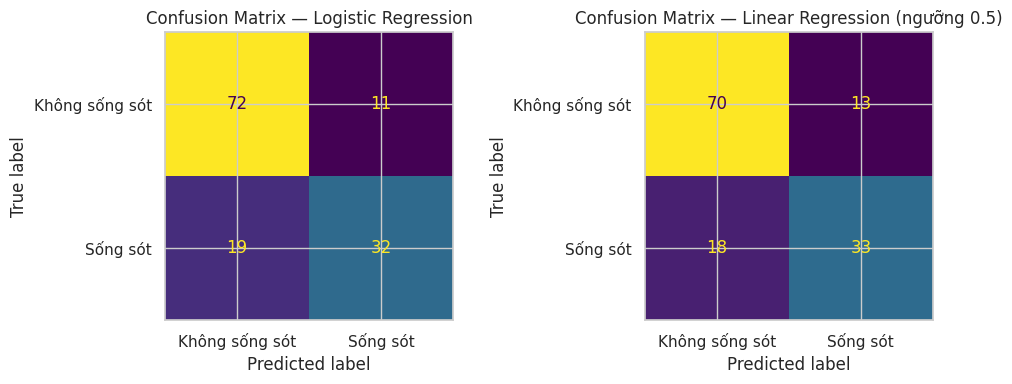

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_log = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm_log, display_labels=["Không sống sót", "Sống sót"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix — Logistic Regression")

cm_lin = confusion_matrix(y_test, y_pred_lin)
ConfusionMatrixDisplay(cm_lin, display_labels=["Không sống sót", "Sống sót"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix — Linear Regression (ngưỡng 0.5)")

plt.tight_layout()
plt.show()


## 7. Nhận xét

- **Về mặt số liệu**: hai mô hình cho kết quả accuracy/F1 khá gần nhau trên tập test này vì bài toán khá "dễ tách tuyến tính" và cỡ mẫu nhỏ.
- **Về mặt bản chất**, **Logistic Regression phù hợp hơn cho bài toán phân loại**:
  - Logistic Regression tối ưu trực tiếp cho phân loại (dùng hàm sigmoid + log-loss), đầu ra là **xác suất thuộc lớp 1** nằm trong khoảng [0, 1] — có ý nghĩa xác suất rõ ràng và ổn định.
  - Linear Regression tối ưu để giảm sai số bình phương (MSE) trên giá trị 0/1 như một biến **liên tục**; đầu ra dự đoán có thể **âm hoặc lớn hơn 1**, không có ý nghĩa xác suất, và việc áp ngưỡng 0.5 chỉ là một cách "vá" tạm để nó hoạt động như phân loại nhị phân.
  - Khi các lớp không cân bằng hoặc dữ liệu có outlier, Linear Regression dễ bị lệch (đường thẳng cố "kéo" theo các điểm ở đầu, ảnh hưởng ngưỡng phân loại), trong khi Logistic Regression bền vững hơn nhờ hàm sigmoid bão hòa ở hai đầu.
- **Kết luận**: dù kết quả số liệu trên tập test này khá tương đồng, **Logistic Regression là lựa chọn đúng đắn về mặt lý thuyết và thực hành** cho bài toán phân loại nhị phân "sống sót hay không", còn Linear Regression chỉ nên dùng minh họa để thấy sự khác biệt, không nên dùng trong thực tế cho bài toán phân loại.
